In [2]:

from scipy.integrate import odeint
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from matplotlib import pyplot as plt, cm
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import solve_ivp
import numpy as np
from matplotlib.animation import FuncAnimation
import sys

#import jax.numpy as jnp

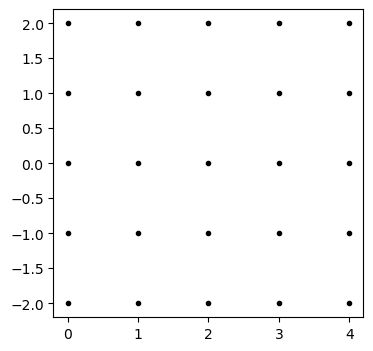

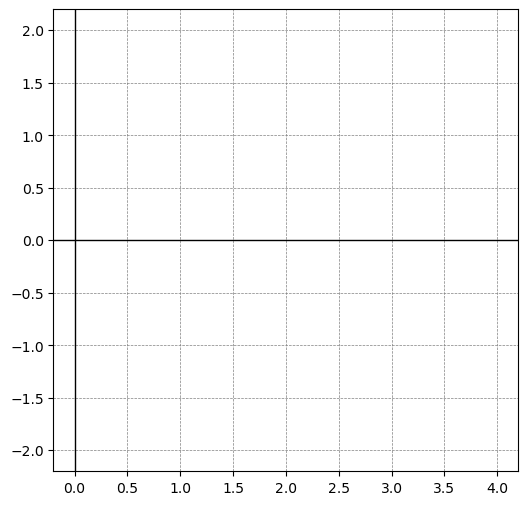

In [3]:
#set up grid
nx,ny = 2,2
x = np.linspace(0, 2*nx, 2*nx+1)
y = np.linspace(-ny, ny, 2*ny+1)
X, Y = np.meshgrid(x, y)
plt.figure(figsize=(4,4))

plt.plot(X, Y, marker='.', color='k', linestyle='none')

L = 10
delta = L/(2*nx+1)
plt.figure(figsize=(6,6))
plt.scatter(X, Y, color='white', s=10) # Plot points
plt.axhline(0, color='black', linewidth=1) # X-axis
plt.axvline(0, color='black', linewidth=1) # Y-axis
plt.grid(True, which='both', color='gray', linestyle='--', linewidth=0.5)
plt.show()

In [4]:
grid = [
    ['a', 'b', 'c'],
    ['d', 'e', 'f'],
    ['g', 'h', 'i']
]

for i in range(len(grid)):          # i iterates over rows (vertical index)
    for j in range(len(grid[i])):    # j iterates over columns (horizontal index)
        print(f"Coordinate ({i}, {j}): {grid[i][j]}")

Coordinate (0, 0): a
Coordinate (0, 1): b
Coordinate (0, 2): c
Coordinate (1, 0): d
Coordinate (1, 1): e
Coordinate (1, 2): f
Coordinate (2, 0): g
Coordinate (2, 1): h
Coordinate (2, 2): i


(201, 201)
0.0005
Fitted parameters: [0.1]


/var/folders/z2/64mpq4x13l77ywvj8pr5fpv00000gn/T/ipykernel_1579/1000377321.py:55: RuntimeWarning: divide by zero encountered in divide
  return A/(x)


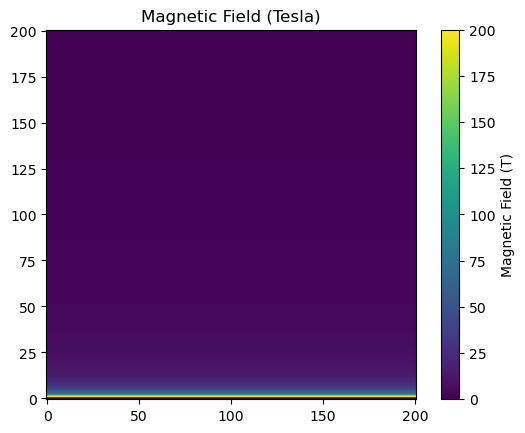

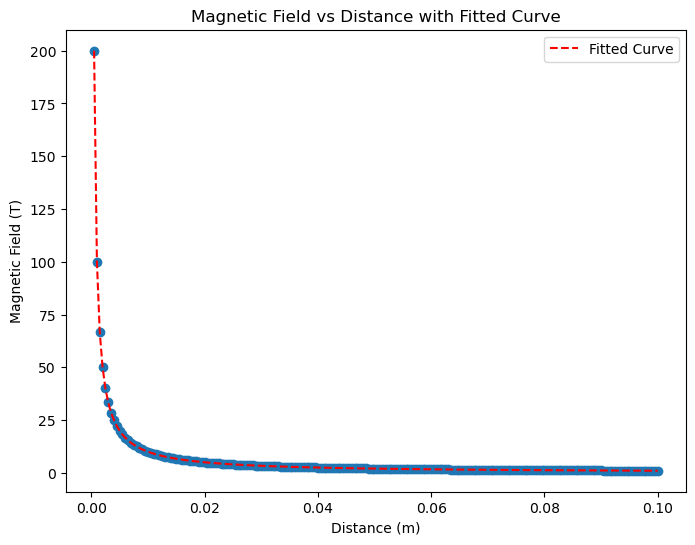

"\nprint(delta)\nplt.plot(r[1:nx+1],B_1[1:nx+1], 'o-')\nplt.show()\nprint(r[1:nx+1])\nprint(np.linspace(1, nx*delta, nx+1))\n"

In [5]:
#set up grid
nx,ny = 200,200
x = np.linspace(0, nx, nx + 1)
y = np.linspace(0, ny, ny + 1)
X, Y = np.meshgrid(x, y)
L = 0.1
delta = L/nx
from scipy.optimize import curve_fit


#charge density
rho = np.zeros([nx+1,ny+1],float)
rho[40:60,:] = -1e12* (1.6e-19) #C/m^2
epsilon = 8.85e-12 #F/m
c = 3e8 #m/s
mu = 4e-7*np.pi #H/m or T·m/A
current = 500000; #Amp


#time steps
steps = 10
dt = 1e-8

B = np.zeros([nx+1,ny+1],float)
B_1 = np.zeros([nx+1],float)
r = np.zeros([nx+1],float)

for i in range(1,nx+1):
    for j in range(0,ny+1):
        B[i,j] = mu*current/(2*np.pi*i*delta)  #Tesla
        B_1[i] = mu*current/(2*np.pi*i*delta)  #Tesla
        r[i] = i*delta

#magnetic field
'''
midplane = 10
for s in range(0,nx):
    if s < midplane:
        magnetic_field = mu*current/(2*np.pi*(midplane - s)*delta) 
    elif s > midplane :
        magnetic_field = mu*current/(2*np.pi*(s-midplane)*delta) #Tesla
    B.append(magnetic_field)
'''


#B = np.tile(B,(ny,1)).T
print (B.shape)
plt.imshow(B, origin = 'lower')
plt.colorbar(label = 'Magnetic Field (T)')
#plt.contour(X, Y, B, levels=20, cmap='Blues')
plt.title('Magnetic Field (Tesla)')
print(delta)

def inverse(x,A):
    return A/(x)

popt, pcov = curve_fit(inverse, r[1:nx+1], B_1[1:nx+1])
A_fit = popt[0]
print("Fitted parameters:", popt)
plt.figure(figsize=(8,6))
x_fit = np.zeros([nx+1],float)
for i in range(1,nx+1):
    x_fit[i] = i*delta
y_fit = inverse(x_fit, A_fit)
plt.plot(x_fit, y_fit , 'r--', label='Fitted Curve')
plt.xlabel('Distance (m)')
plt.ylabel('Magnetic Field (T)')
plt.title('Magnetic Field vs Distance with Fitted Curve')
plt.legend()
plt.scatter(r[1:nx+1], B_1[1:nx+1], label='Data Points')

plt.show()
'''
print(delta)
plt.plot(r[1:nx+1],B_1[1:nx+1], 'o-')
plt.show()
print(r[1:nx+1])
print(np.linspace(1, nx*delta, nx+1))
'''

In [6]:
print(0.1+0.2)
print(sys.float_info)
print(sys.float_info.dig)
print(sys.float_info.epsilon)

0.30000000000000004
sys.float_info(max=1.7976931348623157e+308, max_exp=1024, max_10_exp=308, min=2.2250738585072014e-308, min_exp=-1021, min_10_exp=-307, dig=15, mant_dig=53, epsilon=2.220446049250313e-16, radix=2, rounds=1)
15
2.220446049250313e-16


[[-4.  1.  0. ...  0.  0.  0.]
 [ 1. -4.  1. ...  0.  0.  0.]
 [ 0.  0.  1. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ... -4.  1.  0.]
 [ 0.  0.  0. ...  1. -4.  1.]
 [ 0.  0.  0. ...  0.  1. -4.]]


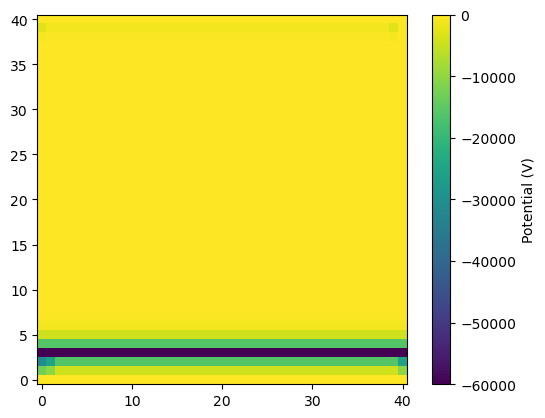

In [59]:
nx, ny = 40, 40
row, col = ny-1,nx+1
conductor = 2
def create_A_draft(row, col):
    num_diag = row*col
    diag = np.full(num_diag, -4)
    lower = np.full((num_diag-1),1)
    upper = np.full((num_diag-1),1)
    identity_up = np.full(num_diag-(nx-1),1.0)
    identity_down = np.full(num_diag-(nx-1),1.0)
    side_up = np.full(row,1, float)
    side_down = np.full(row,1, float)    

    for i in range(1,num_diag-1):
        identity_up[i-1::(ny-1)] = 1+ 1/(2*row)
        identity_down[i-1::(ny-1)] = 1- 1/(2*row)
        row = row-1
        if row == 0:
            row = ny-1
    
    row = ny-1
    for i in range(1,row):
        side_up[i-1::] = 1- 1/(2*row)
        side_down[i-1::] = 1+ 1/(2*row)
        row = row-1
    
    diag[conductor::nx-1] = 1
    lower[conductor-1::nx-1] = 0
    upper[conductor::nx-1] = 0
    identity_up[(conductor)::row] = 0
    identity_down[(conductor)::row] = 0 
    side_up[(conductor)::] = 0
    side_down[(conductor)::] = 0
    
    diagonal = [diag,lower,upper,identity_down,identity_up,side_down,side_up]
    offsets = [0,-1,1,-(nx-1),(nx-1),-nx*(nx-1),nx*(nx-1)]

    return diags(diagonal, offsets, shape =(num_diag, num_diag), format= 'csr')

A = create_A_draft(row, col).toarray()
#print(A.reshape(row*col-2, row*col))
print(A)

#construct boundary vector B
def create_B(rho):
    boundary_conductor = np.zeros(((nx-1)*(ny+1),1),float)
    charge_density = rho[1:nx,0:ny+1].reshape((nx-1)*(ny+1),1,order = 'F')*delta**2*(-1)/epsilon
    boundary_conductor.reshape((nx-1)*(ny+1),1,order = 'F')
    boundary_conductor[conductor::nx-1] = 60000
    boundary_conductor[0::nx-1] = 0

    #lil_B2[0:(nx+1)*(ny-1):(ny-1)] = -rho[0,0:nx+1].reshape((ny+1),1)
    #lil_B2[ny-2:(nx+1)*(ny-1):(ny-1)] = -rho[ny,0:nx+1].reshape(ny+1,1)

    return charge_density - boundary_conductor



def solve_poisson_1(rho):
    phi = np.zeros([nx+1,ny+1],float)
    A = create_A_draft(row,col)
    B = create_B(rho)
    phi_flat = phi[1:nx,0:ny+1].flatten(order= 'F') 
    phi_flat= spsolve(A,B)
    phi[1:nx,0:ny+1] = phi_flat.reshape(nx-1,ny+1,order = 'F')
    return phi

rho = np.zeros([nx+1,ny+1],float)
phi = solve_poisson_1(rho)
plt.imshow(phi, origin = 'lower')
plt.colorbar(label = 'Potential (V)')
#plt.contour(X, Y, phi, levels=20, cmap='Blues')

In [46]:
print(phi[25,100])

1977074.9664867802


In [114]:
nx, ny = 200, 200
row, col = nx-1,ny+1
def create_A(row, col):
    num_diag = row*col
    diag = np.full(num_diag, -4)
    lower = np.full((num_diag-1),1)
    upper = np.full((num_diag-1),1)
    identity_up = np.full(num_diag-(nx-1),1.0)
    identity_down = np.full(num_diag-(nx-1),1.0)
    side = np.full(col,1)
    
    for i in range(1,num_diag-(nx-1)):
        identity_up[i::(ny-1)] = 1+ delta/(2*row)
        identity_down[i::(ny-1)] = 1- delta/(2*row)
        row = row-1
        if row == 0:
            row = ny-1
    
    #row = ny-1
    for i in range(row):
        side[i::] = row
        row = row-1

    diagonal = [diag,lower,upper,identity_down,identity_up,side,side]
    offsets = [0,-1,1,-(nx-1),(nx-1),-nx*(ny-1),nx*(ny-1)]

    return diags(diagonal, offsets, shape =(num_diag, num_diag), format= 'csr')


# trial 2: including periodic side boundary
# https://my.ece.utah.edu/~ece6340/LECTURES/Feb1/Nagel%202012%20-%20Solving%20the%20Generalized%20Poisson%20Equation%20using%20FDM.pdf
# Matrix inversion method: instantaneous Poisson's solver


#construct boundary vector B
def create_B(rho):
    lil_B2 = np.zeros(((nx+1)*(ny-1),1),float)
    f = rho[1:nx,0:ny+1].reshape((nx+1)*(ny-1),1,order = 'F')*delta**2*(-1)/epsilon

    lil_B2[0:(nx+1)*(ny-1):(ny-1)] = -rho[0,0:nx+1].reshape((ny+1),1)
    lil_B2[ny-2:(nx+1)*(ny-1):(ny-1)] = -rho[ny,0:nx+1].reshape(ny+1,1)

    return f


def solve_poisson_1(rho):
    phi = np.zeros([nx+1,ny+1],float)
    A = create_A(row,col)
    B = create_B(rho)
    phi_flat = phi[1:nx,0:ny+1].flatten(order= 'F') 
    phi_flat= spsolve(A,B)
    phi[1:nx,0:ny+1] = phi_flat.reshape(nx-1,ny+1,order = 'F')
    return phi


A = create_A(row, col).toarray()
print(A.shape)
print(create_B(rho).shape)


(39999, 39999)
(39999, 1)


In [121]:
def electric_field(phi):
    Ex = np.zeros([nx+1, ny+1], float)
    Ey = np.zeros([nx+1, ny+1], float)

    for i in range(0,nx+1):
        for j in range(0,ny+1):

    #for i in range(1, nx):
    #    for j in range(1, ny):
            #Gemini pointed out how 2D-array indexing works as below:
            #row of an array is 'i' (y-direction)
            #column of an array is 'j' (x-direction)
            Ex[i, j] = -(phi[i, (j + 1)%(nx+1)] - phi[i, (j - 1)%(nx+1)]) / (2*delta)
            Ey[i, j] = -(phi[(i + 1)%(ny+1), j] - phi[(i - 1)%(ny+1), j]) / (2*delta)


    plt.show()
    return Ex, Ey

def velocity(Ex, Ey, B):
    vx = np.zeros([nx+1, ny+1], float)
    vy = np.zeros([nx+1, ny+1], float)

    for i in range(0,nx+1):
        for j in range(0,ny+1):

   # for i in range(1, nx):
    #    for j in range(1, ny):
            vx[i, j] = Ey[i, j] / B[i, j]
            vy[i, j] = -Ex[i, j] / B[i, j]  

    return vx, vy

#forward Euler method
def forward_euler_charge_density(rho, vx, vy, dt):
    #rho_new_time = rho.copy()
    for n in range(1):
        rho_new_time = rho.copy()
        for i in range(1, nx):
            for j in range(1, ny):
                # not sure vx and vy should be at i,j or i+1,j or i-1,j
                rho[i, j] = rho[i, j] - dt *( (rho_new_time[i +1, j]  - rho_new_time[i - 1, j] )* vy[i, j] /  (2*delta) +
                                                    (rho_new_time[i, j+1]  - rho_new_time[i, j - 1] ) * vx[i, j]/ (2*delta)  )
                #rho[i, j] = rho_new_time[i, j] - dt *( (rho_new_time[i, j]  - rho_new_time[i - 1, j] )* vy[i, j] /  (1*delta) +
                #                                   (rho_new_time[i, j]  - rho_new_time[i, j - 1] ) * vx[i, j]/ (1*delta)  )
                #rho_new_time[i, j] = rho[i, j] - dt * ( (rho[i , j] * vx[i, j] - rho[i - 1, j] * vx[i - 1, j]) /  delta +
                #                                    (rho[i, j] * vy[i, j] - rho[i, j - 1] * vy[i, j - 1]) / delta )
                rho[0,:] = 0
                rho[nx,:]=0
    return rho

def solve_continuity(rho, vx, vy, dt):
    for n in range (1):
        rho_new = rho.copy()
        for i in range (1,nx):
            for j in range (ny+1):
                #Gemini helped me debug the indexing issue (out of bounds): keep grounding boundaries fixed and updating the sides only by wrapping around
                #Google how negative indexing works in Python
                rho[i,j] = rho_new[i,j] - dt*( (rho_new[i+1,j]-rho_new[i-1,j])*vy[i,j]/(2*delta) + 
                                                   (rho_new[i,(j+1)%(ny+1)]-rho_new[i,(j-1)%(ny+1)])*vx[i,j]/(2*delta) )

        rho[0,:] = 0
        rho[nx,:]=0
    return rho

   
# not sure if this is correct
def charge_density_ode(time_span, rho, vx, vy):
    rho= rho.reshape((nx+1, ny+1))
    dndt = np.zeros_like(rho)
    #dndt[0, :] = 0
    #dndt[nx, :] = 0
       
    for i in range(1, nx):
        for j in range(1, ny):
            dndt[i, j] = - ( (rho[i + 1, j]  - rho[i - 1, j] ) * vx[i , j]/ (2 * delta) +
                             (rho[i, j + 1]  - rho[i, j - 1] ) * vy[i, j ]/ (2 * delta) )
    return dndt.flatten()

def solve_rho_ode(vx,vy,rho):
    #vx, vy = velocity(Ex, Ey, B)
    time_span = (0.0, 0.01)
    time_intervals = np.linspace(0.0, 0.01,20)
    rho_0 = rho.flatten()
    sol = solve_ivp(charge_density_ode, time_span, rho_0, method='RK45', t_eval=time_intervals, args=(vx, vy))
    rho_new = sol.y[:,-1]
    return rho_new.reshape(nx+1, ny+1)

/var/folders/z2/64mpq4x13l77ywvj8pr5fpv00000gn/T/ipykernel_6671/4167134523.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  vx[i, j] = Ey[i, j] / B[i, j]
/var/folders/z2/64mpq4x13l77ywvj8pr5fpv00000gn/T/ipykernel_6671/4167134523.py:30: RuntimeWarning: invalid value encountered in scalar divide
  vy[i, j] = -Ex[i, j] / B[i, j]


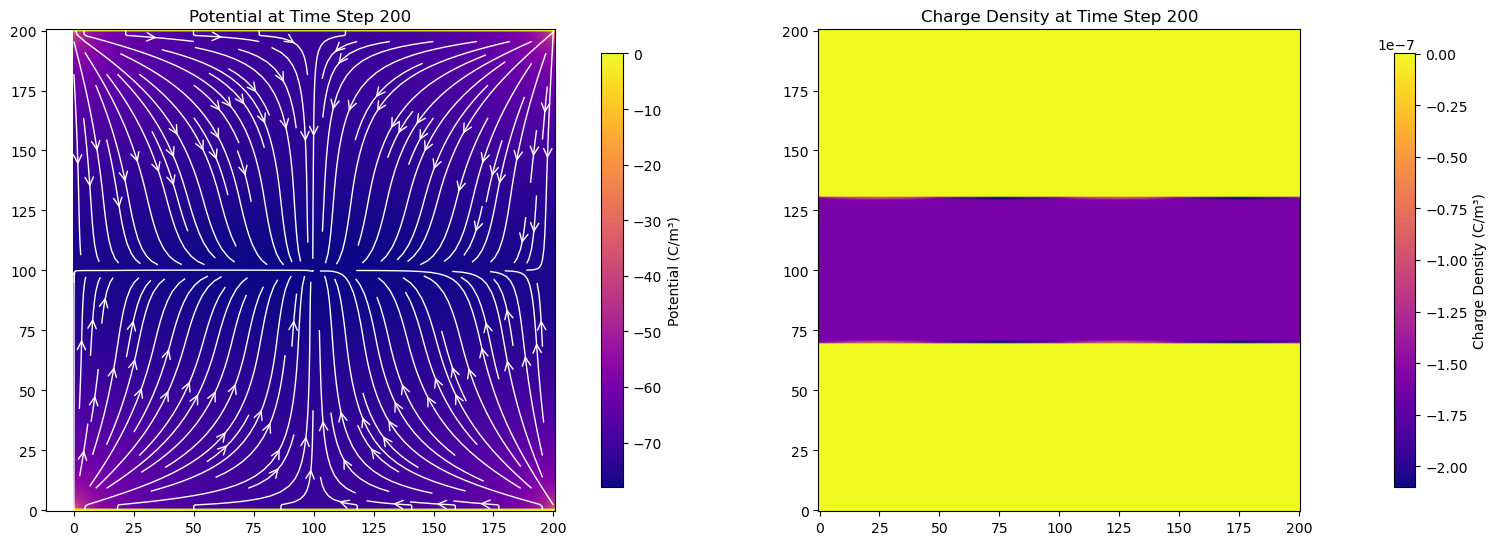

In [126]:
#initial charge density (Daisy)
#slab of electrons in the middle (conductor top and bottom: grounded)
nx,ny = 200,200

rho = np.zeros([nx+1,ny+1],float)
rho[70:131,:]= -1e12* (1.6e-19) 

# small surface perturbations to initial charge density
rho[130,:] += 0.5e-7 *np.sin(0.0628*x)
rho[70,:] += 0.5e-7 *np.sin(0.0628*x)

phi = solve_poisson_1(rho)
Ex, Ey = electric_field(phi)
vx, vy = velocity(Ex, Ey, B)
rho_new = solve_continuity(rho,vx,vy,dt)



fig = plt.figure(figsize=(19, 6))
ax1 = fig.add_subplot(1, 1, 1)
plot_1 = ax1.imshow(rho_new, origin = 'lower',cmap = 'plasma')
plot_1_tiltle = ax1.set_title(f"Charge Density at Time Step {i}")
fig.colorbar(plot_1, ax=ax1, label='Charge Density (C/m³)', shrink=0.9)
        
ax2 = fig.add_subplot(1, 2, 1)
plot_2 = ax2.imshow(phi, origin = 'lower',cmap = 'plasma')
plot_2_tiltle = ax2.set_title(f"Potential at Time Step {i}")
fig.colorbar(plot_2, ax=ax2, label='Potential (C/m³)', shrink=0.9)
        #ax2.streamplot(X, Y, Ex, Ey, color="white", linewidth=1, cmap=plt.cm.inferno,
         #     density=1.5, arrowstyle='->', arrowsize=1.5)

#plt.show()
plt.tight_layout()

ax2.streamplot(X, Y, Ex, Ey, color="white", linewidth=1, cmap=plt.cm.inferno,
              density=1.5, arrowstyle='->', arrowsize=1.5)




'''

plt.imshow(rho, origin = 'lower')
plt.colorbar()


# solve Poisson equation with Matrix Inversion

phi = solve_poisson_1(rho)
plt.imshow(phi, origin = 'lower')
plt.colorbar(label="Potential (V)",shrink=1)
#ax.streamplot(X, Y, Ex, Ey, color="white", linewidth=1, cmap=plt.cm.inferno,
#              density=1.5, arrowstyle='->', arrowsize=1.5)
'''


#plt.imshow(solve_rho_ode(vx,vy,rho), origin = 'lower')
np.set_printoptions(threshold=sys.maxsize, linewidth=200) 
